In [3]:
# use holodeck environment

In [4]:
# making sure the notebook is run from the right directory, as lots of paths are relative to the root directory
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]

if not (PROJECT_ROOT / 'holodeck_output_lib_gp_mcmc').exists():
    raise RuntimeError("Please run Jupyter from the notebooks_and_files_for_final_results directory")


In [5]:
import holodeck as holo
import holodeck
from holodeck.constants import YR, NWTG, SPLC, GYR, PC, MSOL
from holodeck.galaxy_profiles import NFW
from holodeck import utils
from holodeck.librarian import DEF_NUM_FBINS, DEF_NUM_LOUDEST, DEF_PTA_DUR
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from scipy.integrate import solve_ivp, quad
import numpy as np
import kalepy as kale
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import os
import la_forge.core as co
from ceffyl.chain_utils import chain_utils
import la_forge.diagnostics as dg
from chainconsumer.chainconsumer import ChainConsumer
from emcee.autocorr import integrated_time

import numpy as np
import matplotlib.pyplot as plt

PINT not installed. PINT or libstempo are required to use par and tim files.


# Stats analysis

## comparing posteriors for 2k, 4k, 8k trained GP mcmc

for n_training:8000, mtot_array: [5.44e+09 2.40e+09 1.59e+09 1.06e+09 1.44e+07]
data.shape (97400, 20)
the chain is taken from the path: freq_bin2_mtot_1.59e+09_mrat_0.88_redz_0.87
updated chain length: (53267, 6)
data.shape (123090, 20)
the chain is taken from the path: freq_bin2_mtot_1.59e+09_mrat_0.88_redz_0.87
updated chain length: (64252, 6)
data.shape (100000, 20)
the chain is taken from the path: freq_bin2_mtot_1.59e+09_mrat_0.88_redz_0.87
updated chain length: (47621, 6)


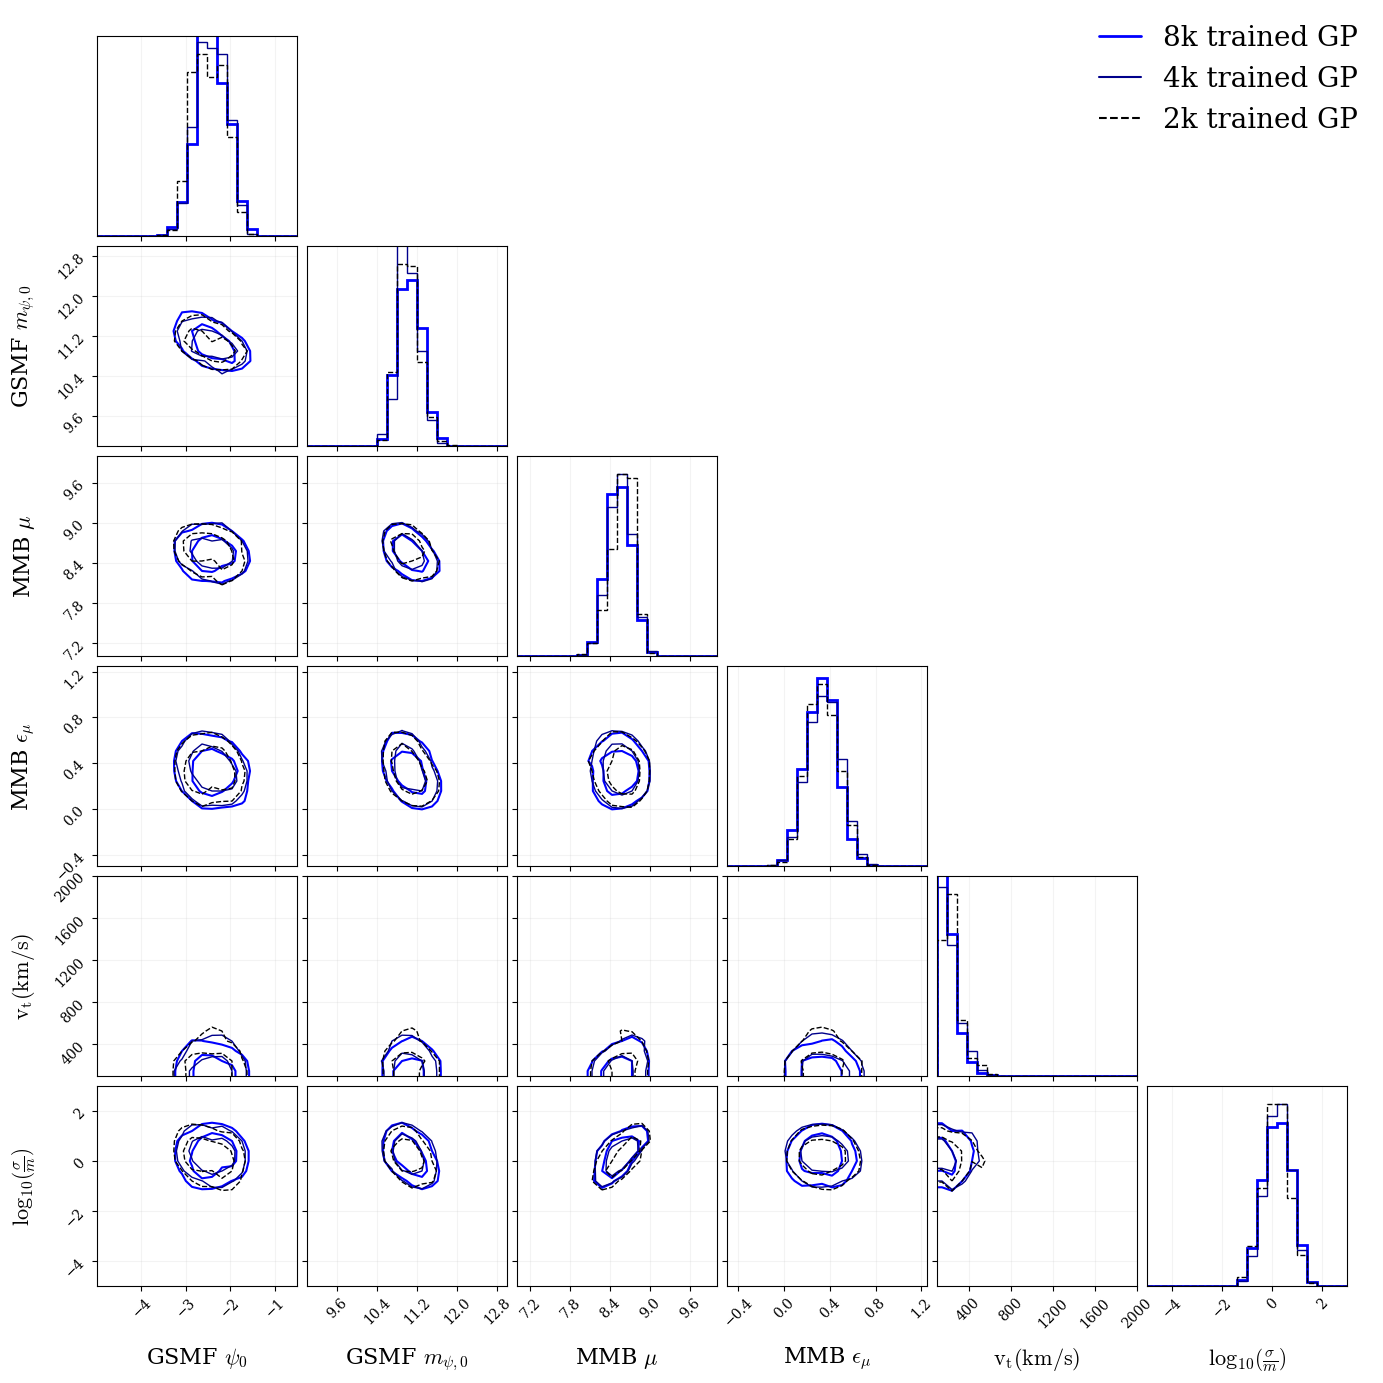

In [6]:
gp_nn = 'gp'

PARAM_SPACE = 'PS_Classic_SIDM_Astro_Extended_Version2'
NSAMPLES = 8000
NREALS = 2000
NFREQS = 5
NFREQS_TRAINING = 5 # for gp training and ceffyl mcmc

# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'

# hd_mp_dp_curn_path = Path(OUTPUT).parent / 'gp_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'
hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'

max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'

# to have paths of all chains for max contri mqz

max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
print(
    f'for n_training:{NSAMPLES}, mtot_array: '
    f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
)
path_list = []
for i in range(len(mtot_array)):
    mtot = mtot_array[i] * MSOL
    mrat = mrat_array[i]
    redz = redz_array[i]
    new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'

    path_list.append(new_path_to_updated_txt_file) 

# for n_training:8000, mtot_array: [5.44e+09 2.40e+09 1.59e+09 1.06e+09 1.44e+07]
# we choose 1.6e9 (index 2) because that is closest to other GP mcmcs and common across 8k NN mcmc
updated_chain_path = path_list[2]
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))

# for no constraints
# idx = np.where(data[:, 5] > 0)


import corner
import numpy as np
import matplotlib.pyplot as plt
# index 0 - psi0
# index 1 - gsmf_mchar0_log10
# index 2 - mmb_mamp_log10
# index 3 - mmb_scatter_dex
# index 4 - vt
# index 5 - sigma0_over_m_times_t_age_by_1Gyr
# index 6 - sigma0_over_m
# index 7 - tdf
# index 8 - sigma_over_m
# index 9 - y
# index 10 - v0

# corner with selected params
data_copy_8k = data.copy()
data_copy_8k = data_copy_8k[idx[0], :]
data_copy_8k[:, 8] = np.log10(data_copy_8k[:, 8]) # for sigma/m
data_copy_8k = data_copy_8k[:, [0, 1, 2, 3, 4, 8]]

print(f'updated chain length: {data_copy_8k.shape}')
# print(f'path to updated mcmc chain: {updated_chain_path}')

##############################################################
NSAMPLES = 4000
# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'
hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'

#######################################################################################################################
# max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'
# # to have paths of all chains for max contri mqz
# max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
# mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
# mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
# redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
# print(
#     f'\nfor n_training:{NSAMPLES}, mtot_array: '
#     f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
# )
# path_list = []
# for i in range(len(mtot_array)):
#     mtot = mtot_array[i] * MSOL
#     mrat = mrat_array[i]
#     redz = redz_array[i]
#     new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'
#     path_list.append(new_path_to_updated_txt_file)

# # for n_training:4000, mtot_array: [4.43e+09 2.17e+07 2.17e+07 6.03e+07 6.03e+07]
# # we choose 4.4e9 (index 0) because that is closest to 1.6e9, whose choice is explained above)
# updated_chain_path = path_list[0]
####################################################################################################################
updated_chain_path = hd_mp_dp_curn_path / 'stats_analysis_fixed_mtot_to_8k_max_contri' / 'freq_bin2_mtot_1.59e+09_mrat_0.88_redz_0.87' / 'updated_chain_1_with_sigma_over_m.txt'
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))
data_copy_4k = data.copy()
data_copy_4k = data_copy_4k[idx[0], :]
data_copy_4k[:, 8] = np.log10(data_copy_4k[:, 8]) # for sigma/m
data_copy_4k = data_copy_4k[:, [0, 1, 2, 3, 4, 8]]
print(f'updated chain length: {data_copy_4k.shape}')

##############################################################
NSAMPLES = 2000
# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'
hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'
#######################################################################################################################
# max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'
# # to have paths of all chains for max contri mqz
# max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
# mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
# mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
# redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
# print(
#     f'\nfor n_training:{NSAMPLES}, mtot_array: '
#     f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
# )
# path_list = []
# for i in range(len(mtot_array)):
#     mtot = mtot_array[i] * MSOL
#     mrat = mrat_array[i]
#     redz = redz_array[i]
#     new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'
#     path_list.append(new_path_to_updated_txt_file)

# # for n_training:4000, mtot_array: [4.43e+09 2.17e+07 2.17e+07 6.03e+07 6.03e+07]
# # we choose 4.4e9 (index 0) because that is closest to 1.6e9, whose choice is explained above)
# updated_chain_path = path_list[0]
####################################################################################################################
updated_chain_path = hd_mp_dp_curn_path / 'stats_analysis_fixed_mtot_to_8k_max_contri' / 'freq_bin2_mtot_1.59e+09_mrat_0.88_redz_0.87' / 'updated_chain_1_with_sigma_over_m.txt'
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))
data_copy_2k = data.copy()
data_copy_2k = data_copy_2k[idx[0], :]
data_copy_2k[:, 8] = np.log10(data_copy_2k[:, 8]) # for sigma/m
data_copy_2k = data_copy_2k[:, [0, 1, 2, 3, 4, 8]]
print(f'updated chain length: {data_copy_2k.shape}')



labels = [r"GSMF $\psi_0$", r"GSMF $m_{\psi, 0}$", r"MMB $\mu$", r"MMB $\epsilon_{\mu}$", r"$\mathrm{v_t (km/s)}$", r"$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$"]

# Define x-axis limits
ranges = [(-5, -0.5), (9, 13), (7, 10), (-0.5, 1.25), (100, 2000), (-5, 3)] # changed the lower limit on vt chain from 0 to 100 to avoid the edge effect (29.10.2025)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# First (8k) — filled green
fig = corner.corner(
    data_copy_8k,
    labels=labels,
    range=ranges,
    show_titles=False,
    fill_contours=False,
    plot_contours=True,
    plot_density=False,
    plot_datapoints=False,
    label_kwargs={"fontsize": 16},
    levels=[0.68, 0.95],
    color='blue',
    hist_kwargs={
        "linestyle": "-",
        "linewidth": 2,
        "density": True
    }
)

# Second (4k) — solid grey
corner.corner(
    data_copy_4k,
    fig=fig,
    range=ranges,
    plot_contours=True,
    plot_density=False,
    fill_contours=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
    color='darkblue',
    contour_kwargs={
        "linestyles": "solid",
        "linewidths": 1
    },
    hist_kwargs={
        "linestyle": "-",
        "linewidth":1,
        "density": True
    }
)

# Third (2k) — dashed black
corner.corner(
    data_copy_2k,
    fig=fig,
    range=ranges,
    plot_contours=True,
    plot_density=False,
    fill_contours=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
    color='black',
    contour_kwargs={
        "linestyles": "dashed",
        "linewidths": 1
    },
    hist_kwargs={
        "linestyle": "--",
        "linewidth": 1,
        "density": True
    }
)

if gp_nn=='gp':
    gp_nn_plt='GP'
else:
    gp_nn_plt='NN'

legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label=f'8k trained {gp_nn_plt}'),
    Line2D([0], [0], color='darkblue', lw=1.5, linestyle='-', label=f'4k trained {gp_nn_plt}'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label=f'2k trained {gp_nn_plt}')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=20,
    frameon=False
)

plt.show()


# Table of median and +- 1 sigma values

In [7]:
def summary_stats(chain):
    median = np.median(chain, axis=0)
    p16 = np.percentile(chain, 16, axis=0)
    p84 = np.percentile(chain, 84, axis=0)
    return median, p16, p84

med_8k, p16_8k, p84_8k = summary_stats(data_copy_8k)
med_4k, p16_4k, p84_4k = summary_stats(data_copy_4k)
med_2k, p16_2k, p84_2k = summary_stats(data_copy_2k)

labels = [
    r"GSMF $\psi_0$",
    r"GSMF $m_{\psi, 0}$",
    r"MMB $\mu$",
    r"MMB $\epsilon_{\mu}$",
    r"$\mathrm{v_t (km/s)}$",
    r"$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$"
]

print(f"{'Parameter':<25} {'8k':>25} {'4k':>25} {'2k':>25}")
print("-"*100)

for i, name in enumerate(labels):
    
    def fmt(med, p16, p84, i):
        plus  = p84[i] - med[i]
        minus = med[i] - p16[i]
        return f"{med[i]:.2f} (+{plus:.2f}, -{minus:.2f})"
    
    str_8k = fmt(med_8k, p16_8k, p84_8k, i)
    str_4k = fmt(med_4k, p16_4k, p84_4k, i)
    str_2k = fmt(med_2k, p16_2k, p84_2k, i)
    
    print(f"{name:<25} {str_8k:>25} {str_4k:>25} {str_2k:>25}")


Parameter                                        8k                        4k                        2k
----------------------------------------------------------------------------------------------------
GSMF $\psi_0$                  -2.43 (+0.38, -0.31)      -2.42 (+0.36, -0.35)      -2.50 (+0.40, -0.36)
GSMF $m_{\psi, 0}$             11.05 (+0.25, -0.23)      11.01 (+0.24, -0.16)      11.02 (+0.24, -0.20)
MMB $\mu$                       8.53 (+0.19, -0.18)       8.55 (+0.18, -0.18)       8.61 (+0.14, -0.21)
MMB $\epsilon_{\mu}$            0.33 (+0.13, -0.14)       0.35 (+0.14, -0.15)       0.33 (+0.15, -0.13)
$\mathrm{v_t (km/s)}$       183.37 (+93.50, -74.86)  189.97 (+118.02, -78.85)   222.55 (+86.85, -83.38)
$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$       0.22 (+0.56, -0.57)       0.25 (+0.50, -0.52)       0.18 (+0.50, -0.53)


In [8]:
def latex_table_3way(labels,
                    med_8k, p16_8k, p84_8k,
                    med_4k, p16_4k, p84_4k,
                    med_2k, p16_2k, p84_2k,
                    caption="Parameter constraints for different MCMC resolutions",
                    label="tab:params_resolution"):
    
    lines = []
    lines.append(r"\begin{table}")
    lines.append(r"\centering")
    lines.append(r"\renewcommand{\arraystretch}{1.6}")
    lines.append(r"\begin{tabular}{|l|r|r|r|}")
    lines.append(r"\hline")
    lines.append(r"Parameter & 8000 & 4000 & 2000 \\")
    lines.append(r"\hline")
        
    for i, name in enumerate(labels):
        
        def fmt(med, p16, p84):
            plus  = p84[i] - med[i]
            minus = med[i] - p16[i]
            return f"${med[i]:.2f}^{{+{plus:.2f}}}_{{-{minus:.2f}}}$"
        
        val_8k = fmt(med_8k, p16_8k, p84_8k)
        val_4k = fmt(med_4k, p16_4k, p84_4k)
        val_2k = fmt(med_2k, p16_2k, p84_2k)
        
        lines.append(f"{name} & {val_8k} & {val_4k} & {val_2k} \\\\")
    
    lines.append(r"\hline")
    lines.append(r"\end{tabular}")
    lines.append(f"\\caption{{{caption}}}")
    lines.append(f"\\label{{{label}}}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

latex_code = latex_table_3way(
    labels,
    med_8k, p16_8k, p84_8k,
    med_4k, p16_4k, p84_4k,
    med_2k, p16_2k, p84_2k
)

print(latex_code)

\begin{table}
\centering
\renewcommand{\arraystretch}{1.6}
\begin{tabular}{|l|r|r|r|}
\hline
Parameter & 8000 & 4000 & 2000 \\
\hline
GSMF $\psi_0$ & $-2.43^{+0.38}_{-0.31}$ & $-2.42^{+0.36}_{-0.35}$ & $-2.50^{+0.40}_{-0.36}$ \\
GSMF $m_{\psi, 0}$ & $11.05^{+0.25}_{-0.23}$ & $11.01^{+0.24}_{-0.16}$ & $11.02^{+0.24}_{-0.20}$ \\
MMB $\mu$ & $8.53^{+0.19}_{-0.18}$ & $8.55^{+0.18}_{-0.18}$ & $8.61^{+0.14}_{-0.21}$ \\
MMB $\epsilon_{\mu}$ & $0.33^{+0.13}_{-0.14}$ & $0.35^{+0.14}_{-0.15}$ & $0.33^{+0.15}_{-0.13}$ \\
$\mathrm{v_t (km/s)}$ & $183.37^{+93.50}_{-74.86}$ & $189.97^{+118.02}_{-78.85}$ & $222.55^{+86.85}_{-83.38}$ \\
$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$ & $0.22^{+0.56}_{-0.57}$ & $0.25^{+0.50}_{-0.52}$ & $0.18^{+0.50}_{-0.53}$ \\
\hline
\end{tabular}
\caption{Parameter constraints for different MCMC resolutions}
\label{tab:params_resolution}
\end{table}


## comparing posteriors for 2k, 4k, 8k trained NN mcmc

for n_training:8000, mtot_array: [6.68e+09 3.61e+09 1.96e+09 1.59e+09 1.06e+09]


data.shape (127744, 20)
the chain is taken from the path: freq_bin3_mtot_1.59e+09_mrat_0.96_redz_1.05
updated chain length: (55922, 6)
data.shape (113900, 20)
the chain is taken from the path: freq_bin2_mtot_1.59e+09_mrat_0.88_redz_0.87
updated chain length: (57813, 6)
data.shape (130000, 20)
the chain is taken from the path: freq_bin2_mtot_1.59e+09_mrat_0.88_redz_0.87
updated chain length: (65998, 6)


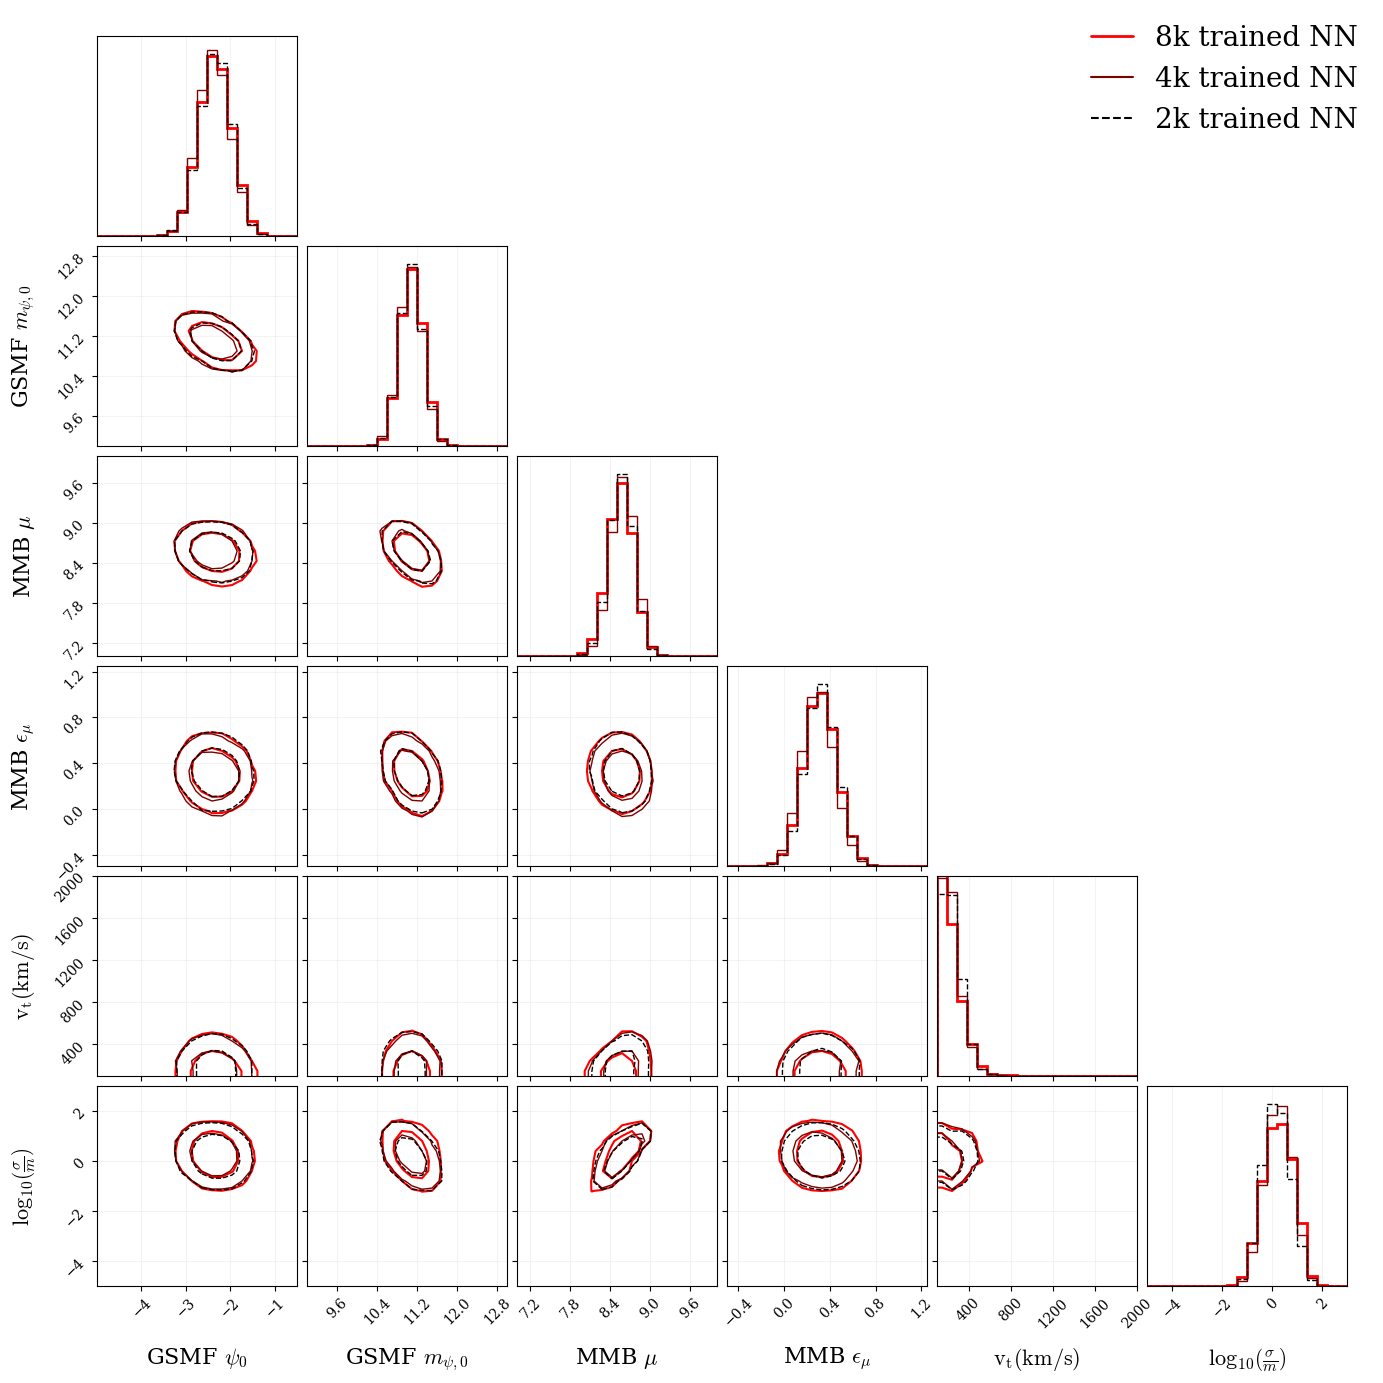

In [9]:
gp_nn = 'nn'

PARAM_SPACE = 'PS_Classic_SIDM_Astro_Extended_Version2'
NSAMPLES = 8000
NREALS = 2000
NFREQS = 5
NFREQS_TRAINING = 5 # for gp training and ceffyl mcmc

# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'

hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'

max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'

# to have paths of all chains for max contri mqz

max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
print(
    f'for n_training:{NSAMPLES}, mtot_array: '
    f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
)
path_list = []
for i in range(len(mtot_array)):
    mtot = mtot_array[i] * MSOL
    mrat = mrat_array[i]
    redz = redz_array[i]
    new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'

    path_list.append(new_path_to_updated_txt_file) 

# for n_training:8000, mtot_array: [6.68e+09 3.61e+09 1.96e+09 1.59e+09 1.06e+09]
# we choose 1.6e9 (index 3) because that is closest to other NN mcmcs and common across 8k GP mcmc
updated_chain_path = path_list[3]
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))

# for no constraints
# idx = np.where(data[:, 5] > 0)


import corner
import numpy as np
import matplotlib.pyplot as plt
# index 0 - psi0
# index 1 - gsmf_mchar0_log10
# index 2 - mmb_mamp_log10
# index 3 - mmb_scatter_dex
# index 4 - vt
# index 5 - sigma0_over_m_times_t_age_by_1Gyr
# index 6 - sigma0_over_m
# index 7 - tdf
# index 8 - sigma_over_m
# index 9 - y
# index 10 - v0

# corner with selected params
data_copy_8k = data.copy()
data_copy_8k = data_copy_8k[idx[0], :]
data_copy_8k[:, 8] = np.log10(data_copy_8k[:, 8]) # for sigma/m
data_copy_8k = data_copy_8k[:, [0, 1, 2, 3, 4, 8]]

print(f'updated chain length: {data_copy_8k.shape}')
# print(f'path to updated mcmc chain: {updated_chain_path}')

##############################################################
NSAMPLES = 4000
# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'
hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'
#######################################################################################################################
# max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'
# # to have paths of all chains for max contri mqz
# max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
# mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
# mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
# redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
# print(
#     f'\nfor n_training:{NSAMPLES}, mtot_array: '
#     f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
# )
# path_list = []
# for i in range(len(mtot_array)):
#     mtot = mtot_array[i] * MSOL
#     mrat = mrat_array[i]
#     redz = redz_array[i]
#     new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'
#     path_list.append(new_path_to_updated_txt_file)

# # for n_training:4000, mtot_array: [4.43e+09 2.17e+07 2.17e+07 6.03e+07 6.03e+07]
# # we choose 4.4e9 (index 0) because that is closest to 1.6e9, whose choice is explained above)
# updated_chain_path = path_list[0]
####################################################################################################################
updated_chain_path = hd_mp_dp_curn_path / 'stats_analysis_fixed_mtot_to_8k_max_contri' / 'freq_bin2_mtot_1.59e+09_mrat_0.88_redz_0.87' / 'updated_chain_1_with_sigma_over_m.txt'
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))
data_copy_4k = data.copy()
data_copy_4k = data_copy_4k[idx[0], :]
data_copy_4k[:, 8] = np.log10(data_copy_4k[:, 8]) # for sigma/m
data_copy_4k = data_copy_4k[:, [0, 1, 2, 3, 4, 8]]
print(f'updated chain length: {data_copy_4k.shape}')

##############################################################
NSAMPLES = 2000
# correct prior implementation
OUTPUT = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{NSAMPLES}_r{NREALS}_f{NFREQS}/library'
hd_mp_dp_curn_path = Path(OUTPUT).parent / f'{gp_nn}_mcmc_log_likelihood_all_freqs' / 'ceffyl_output_hd_mp_dp_curn'
#######################################################################################################################
# max_contri_mqz_5_freqs_dict_path = hd_mp_dp_curn_path / 'stats_analysis' / 'max_contri_mqz_5_freqs_dict.npz'
# # to have paths of all chains for max contri mqz
# max_contri_mqz_5_freqs_dict = np.load(max_contri_mqz_5_freqs_dict_path)
# mtot_array = max_contri_mqz_5_freqs_dict["mtot_array"]
# mrat_array = max_contri_mqz_5_freqs_dict["mrat_array"]
# redz_array = max_contri_mqz_5_freqs_dict["redz_array"]
# print(
#     f'\nfor n_training:{NSAMPLES}, mtot_array: '
#     f'{np.array2string(mtot_array, formatter={"float_kind": lambda x: f"{x:.2e}"})}'
# )
# path_list = []
# for i in range(len(mtot_array)):
#     mtot = mtot_array[i] * MSOL
#     mrat = mrat_array[i]
#     redz = redz_array[i]
#     new_path_to_updated_txt_file =Path(max_contri_mqz_5_freqs_dict_path).parent / f'freq_bin{i}_mtot_{(mtot/MSOL):.2e}_mrat_{mrat:.2f}_redz_{redz:.2f}/updated_chain_1_with_sigma_over_m.txt'
#     path_list.append(new_path_to_updated_txt_file)

# # for n_training:4000, mtot_array: [4.43e+09 2.17e+07 2.17e+07 6.03e+07 6.03e+07]
# # we choose 4.4e9 (index 0) because that is closest to 1.6e9, whose choice is explained above)
# updated_chain_path = path_list[0]
####################################################################################################################
updated_chain_path = hd_mp_dp_curn_path / 'stats_analysis_fixed_mtot_to_8k_max_contri' / 'freq_bin2_mtot_1.59e+09_mrat_0.88_redz_0.87' / 'updated_chain_1_with_sigma_over_m.txt'
data = np.loadtxt(updated_chain_path)
print(f'data.shape {data.shape}')
print(f'the chain is taken from the path: {updated_chain_path.parent.name}')
# to apply grey region exclusion from acd fig.4 (sigma0/m * t_age/1GYR > 0.25) and (tdf > 50 Myr) and (tdf < 13.79 Gyrs)
idx = np.where((data[:, 5] > 0.25) & (data[:, 7]/(50*1e6*YR) > 1.0) & (data[:, 7]/GYR < 13.79))
data_copy_2k = data.copy()
data_copy_2k = data_copy_2k[idx[0], :]
data_copy_2k[:, 8] = np.log10(data_copy_2k[:, 8]) # for sigma/m
data_copy_2k = data_copy_2k[:, [0, 1, 2, 3, 4, 8]]
print(f'updated chain length: {data_copy_2k.shape}')



labels = [r"GSMF $\psi_0$", r"GSMF $m_{\psi, 0}$", r"MMB $\mu$", r"MMB $\epsilon_{\mu}$", r"$\mathrm{v_t (km/s)}$", r"$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$"]

# Define x-axis limits
ranges = [(-5, -0.5), (9, 13), (7, 10), (-0.5, 1.25), (100, 2000), (-5, 3)] # changed the lower limit on vt chain from 0 to 100 to avoid the edge effect (29.10.2025)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# First (8k) — filled green
fig = corner.corner(
    data_copy_8k,
    labels=labels,
    range=ranges,
    show_titles=False,
    fill_contours=False,
    plot_contours=True,
    plot_density=False,
    plot_datapoints=False,
    label_kwargs={"fontsize": 16},
    levels=[0.68, 0.95],
    color='red',
    hist_kwargs={
        "linestyle": "-",
        "linewidth": 2,
        "density": True
    }
)

# Second (4k) — solid grey
corner.corner(
    data_copy_4k,
    fig=fig,
    range=ranges,
    plot_contours=True,
    plot_density=False,
    fill_contours=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
    color='maroon',
    contour_kwargs={
        "linestyles": "solid",
        "linewidths": 1
    },
    hist_kwargs={
        "linestyle": "-",
        "linewidth":1,
        "density": True
    }
)

# Third (2k) — dashed black
corner.corner(
    data_copy_2k,
    fig=fig,
    range=ranges,
    plot_contours=True,
    plot_density=False,
    fill_contours=False,
    plot_datapoints=False,
    levels=[0.68, 0.95],
    color='black',
    contour_kwargs={
        "linestyles": "dashed",
        "linewidths": 1
    },
    hist_kwargs={
        "linestyle": "--",
        "linewidth": 1,
        "density": True
    }
)

if gp_nn=='gp':
    gp_nn_plt='GP'
else:
    gp_nn_plt='NN'

legend_elements = [
    Line2D([0], [0], color='red', lw=2, label=f'8k trained {gp_nn_plt}'),
    Line2D([0], [0], color='maroon', lw=1.5, linestyle='-', label=f'4k trained {gp_nn_plt}'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label=f'2k trained {gp_nn_plt}')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=20,
    frameon=False
)

plt.show()

# Table of median and +- 1 sigma values

In [10]:
def summary_stats(chain):
    median = np.median(chain, axis=0)
    p16 = np.percentile(chain, 16, axis=0)
    p84 = np.percentile(chain, 84, axis=0)
    return median, p16, p84

med_8k, p16_8k, p84_8k = summary_stats(data_copy_8k)
med_4k, p16_4k, p84_4k = summary_stats(data_copy_4k)
med_2k, p16_2k, p84_2k = summary_stats(data_copy_2k)

labels = [
    r"GSMF $\psi_0$",
    r"GSMF $m_{\psi, 0}$",
    r"MMB $\mu$",
    r"MMB $\epsilon_{\mu}$",
    r"$\mathrm{v_t (km/s)}$",
    r"$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$"
]

print(f"{'Parameter':<25} {'8k':>25} {'4k':>25} {'2k':>25}")
print("-"*100)

for i, name in enumerate(labels):
    
    def fmt(med, p16, p84, i):
        plus  = p84[i] - med[i]
        minus = med[i] - p16[i]
        return f"{med[i]:.2f} (+{plus:.2f}, -{minus:.2f})"
    
    str_8k = fmt(med_8k, p16_8k, p84_8k, i)
    str_4k = fmt(med_4k, p16_4k, p84_4k, i)
    str_2k = fmt(med_2k, p16_2k, p84_2k, i)
    
    print(f"{name:<25} {str_8k:>25} {str_4k:>25} {str_2k:>25}")


Parameter                                        8k                        4k                        2k
----------------------------------------------------------------------------------------------------
GSMF $\psi_0$                  -2.34 (+0.37, -0.36)      -2.37 (+0.36, -0.36)      -2.34 (+0.35, -0.36)
GSMF $m_{\psi, 0}$             11.09 (+0.24, -0.23)      11.07 (+0.23, -0.23)      11.09 (+0.23, -0.23)
MMB $\mu$                       8.56 (+0.19, -0.19)       8.59 (+0.18, -0.18)       8.57 (+0.18, -0.18)
MMB $\epsilon_{\mu}$            0.31 (+0.14, -0.14)       0.29 (+0.14, -0.14)       0.32 (+0.14, -0.14)
$\mathrm{v_t (km/s)}$      184.37 (+130.28, -83.03)  210.70 (+107.71, -82.02)  217.18 (+113.02, -90.96)
$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$       0.26 (+0.62, -0.61)       0.26 (+0.56, -0.56)       0.17 (+0.57, -0.54)


In [11]:
def latex_table_3way(labels,
                    med_8k, p16_8k, p84_8k,
                    med_4k, p16_4k, p84_4k,
                    med_2k, p16_2k, p84_2k,
                    caption="Parameter constraints for different MCMC resolutions",
                    label="tab:params_resolution"):
    
    lines = []
    lines.append(r"\begin{table}")
    lines.append(r"\centering")
    lines.append(r"\renewcommand{\arraystretch}{1.6}")
    lines.append(r"\begin{tabular}{|l|r|r|r|}")
    lines.append(r"\hline")
    lines.append(r"Parameter & 8000 & 4000 & 2000 \\")
    lines.append(r"\hline")
    
    for i, name in enumerate(labels):
        
        def fmt(med, p16, p84):
            plus  = p84[i] - med[i]
            minus = med[i] - p16[i]
            return f"${med[i]:.2f}^{{+{plus:.2f}}}_{{-{minus:.2f}}}$"
        
        val_8k = fmt(med_8k, p16_8k, p84_8k)
        val_4k = fmt(med_4k, p16_4k, p84_4k)
        val_2k = fmt(med_2k, p16_2k, p84_2k)
        
        lines.append(f"{name} & {val_8k} & {val_4k} & {val_2k} \\\\")
    
    lines.append(r"\hline")
    lines.append(r"\end{tabular}")
    lines.append(f"\\caption{{{caption}}}")
    lines.append(f"\\label{{{label}}}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

latex_code = latex_table_3way(
    labels,
    med_8k, p16_8k, p84_8k,
    med_4k, p16_4k, p84_4k,
    med_2k, p16_2k, p84_2k
)

print(latex_code)

\begin{table}
\centering
\renewcommand{\arraystretch}{1.6}
\begin{tabular}{|l|r|r|r|}
\hline
Parameter & 8000 & 4000 & 2000 \\
\hline
GSMF $\psi_0$ & $-2.34^{+0.37}_{-0.36}$ & $-2.37^{+0.36}_{-0.36}$ & $-2.34^{+0.35}_{-0.36}$ \\
GSMF $m_{\psi, 0}$ & $11.09^{+0.24}_{-0.23}$ & $11.07^{+0.23}_{-0.23}$ & $11.09^{+0.23}_{-0.23}$ \\
MMB $\mu$ & $8.56^{+0.19}_{-0.19}$ & $8.59^{+0.18}_{-0.18}$ & $8.57^{+0.18}_{-0.18}$ \\
MMB $\epsilon_{\mu}$ & $0.31^{+0.14}_{-0.14}$ & $0.29^{+0.14}_{-0.14}$ & $0.32^{+0.14}_{-0.14}$ \\
$\mathrm{v_t (km/s)}$ & $184.37^{+130.28}_{-83.03}$ & $210.70^{+107.71}_{-82.02}$ & $217.18^{+113.02}_{-90.96}$ \\
$\mathrm{log}_{10} \left( \frac{\sigma}{m} \right)$ & $0.26^{+0.62}_{-0.61}$ & $0.26^{+0.56}_{-0.56}$ & $0.17^{+0.57}_{-0.54}$ \\
\hline
\end{tabular}
\caption{Parameter constraints for different MCMC resolutions}
\label{tab:params_resolution}
\end{table}
